In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import sys
sys.path.append("/source/cyberbattle") 

import os
import logging
import gymnasium as gym
import cyberbattle._env.cyberbattle_env as cyberbattle_env
import cyberbattle.agents.baseline.learner as learner
import cyberbattle.agents.baseline.plotting as p
import cyberbattle.agents.baseline.agent_wrapper as w
import cyberbattle.agents.baseline.agent_randomcredlookup as rca
import cyberbattle.agents.baseline.agent_tabularqlearning as tqa
import cyberbattle.agents.baseline.agent_dql as dqla
from cyberbattle.agents.baseline.agent_wrapper import Verbosity
from cyberbattle._env.cyberbattle_env import CyberBattleEnv

from agents.temp import DeepRecurrentQLearnerPolicy as drqn
import agents.temp as tmp

logging.basicConfig(stream=sys.stdout, level=logging.ERROR, format="%(levelname)s: %(message)s")

# Environment Definition

In [20]:
cyberbattlechain_10 = gym.make("CyberBattleChain-v0", size=20, attacker_goal=cyberbattle_env.AttackerGoal(own_atleast_percent=1.0)).unwrapped
gym_env = cyberbattlechain_10 
ep = w.EnvironmentBounds.of_identifiers(maximum_total_credentials=10, maximum_node_count=22, identifiers=cyberbattlechain_10.identifiers)


In [9]:
# Parameters
gymid = "CyberBattleToyCtf-v0"
env_size = None
iteration_count = 1500
training_episode_count = 3
eval_episode_count = 10
maximum_node_count = 12
maximum_total_credentials = 10
plots_dir = "notebooks/output/benchmark/plots"


In [10]:
os.makedirs(plots_dir, exist_ok=True)

# Load the Gym environment
if env_size:
    _gym_env = gym.make(gymid, size=env_size)
else:
    _gym_env = gym.make(gymid)

from typing import cast

gym_env = cast(CyberBattleEnv, _gym_env.unwrapped)
assert isinstance(gym_env, CyberBattleEnv), f"Expected CyberBattleEnv, got {type(gym_env)}"

ep = w.EnvironmentBounds.of_identifiers(maximum_node_count=maximum_node_count, maximum_total_credentials=maximum_total_credentials, identifiers=gym_env.identifiers)

# Evaluation

## Random Agent

In [4]:
# Evaluate the random agent
random_run = learner.epsilon_greedy_search(
    gym_env,
    ep,
    learner=learner.RandomPolicy(),
    episode_count=1,
    iteration_count=500,
    epsilon=1.0,  # purely random
    render=False,
    verbosity=Verbosity.Quiet,
    plot_episodes_length=False,
    title="Random search",
)

###### Random search
Learning with: episode_count=1,iteration_count=500,ϵ=1.0,ϵ_min=0.0, 
  ## Episode: 1/1 'Random search' ϵ=1.0000, 


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 6|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 6|reward:   11.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 1|Iteration 18|reward:   22.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 1|Iteration 18|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 1|Iteration 29|reward:   31.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 1|Iteration 29|reward:   31.0|last_reward_at:   29|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  131.0|last_reward_at:   29|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  131.0|last_reward_at:   34|Elapsed Time: 0:00:00||
Episode 1|Iteration 37|reward:  145.0|last_reward_at:   34|Elapsed Time: 0:00:00||
Episode 1|Iteration 37|reward:  145.0|last_reward_at:   37|Elapsed Time: 0:00:00||
Episode 

  Episode 1 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 3/62 (0.05)
    explore-remote: 6/238 (0.02)
    explore-connect: 3/188 (0.02)
    exploit-local: 0/0 (NaN)
    exploit-remote: 0/0 (NaN)
    exploit-connect: 0/0 (NaN)
  exploit deflected to exploration: 0
simulation ended


## Tabular Q-learning

In [ ]:
# Evaluate a Tabular Q-learning agent
tabularq_run = learner.epsilon_greedy_search(
    gym_env,
    ep,
    learner=tqa.QTabularLearner(ep, gamma=0.015, learning_rate=0.01, exploit_percentile=100),
    episode_count=training_episode_count,
    iteration_count=iteration_count,
    epsilon=0.90,
    epsilon_exponential_decay=5000,
    epsilon_minimum=0.01,
    verbosity=Verbosity.Quiet,
    render=False,
    plot_episodes_length=False,
    title="Tabular Q-learning",
)

In [ ]:
# Evaluate an agent that exploits the Q-table learnt above
tabularq_exploit_run = learner.epsilon_greedy_search(
    gym_env,
    ep,
    learner=tqa.QTabularLearner(ep, trained=tabularq_run["learner"], gamma=0.0, learning_rate=0.0, exploit_percentile=90),
    episode_count=eval_episode_count,
    iteration_count=iteration_count,
    epsilon=0.0,
    render=False,
    verbosity=Verbosity.Quiet,
    title="Exploiting Q-matrix",
)

## Deep Recurrent Q-Learning

In [18]:
# Evaluate the Deep Q-learning agent
drql_run = learner.epsilon_greedy_search(
    cyberbattle_gym_env=gym_env,
    environment_properties=ep,
    learner=tmp.DeepRecurrentQLearnerPolicy(
        ep=ep,
        gamma=0.015,
        replay_memory_size=100000,
        target_update=10,
        batch_size=512,
        # torch default learning rate is 1e-2
        # a large value helps converge in less episodes
        learning_rate=0.01,
    ),
    episode_count=4,
    iteration_count=500,
    epsilon=0.90,
    epsilon_exponential_decay=5000,
    epsilon_minimum=0.10,
    verbosity=Verbosity.Quiet,
    render=False,
    plot_episodes_length=False,
    title="DRQL",
)

###### DRQL
Learning with: episode_count=4,iteration_count=500,ϵ=0.9,ϵ_min=0.1, ϵ_expdecay=5000,γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10
  ## Episode: 1/4 'DRQL' ϵ=0.9000, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 9|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 9|reward:   11.0|last_reward_at:    9|Elapsed Time: 0:00:00||
Episode 1|Iteration 15|reward:   22.0|last_reward_at:    9|Elapsed Time: 0:00:00||
Episode 1|Iteration 15|reward:   22.0|last_reward_at:   15|Elapsed Time: 0:00:00||
Episode 1|Iteration 16|reward:   33.0|last_reward_at:   15|Elapsed Time: 0:00:00||
Episode 1|Iteration 16|reward:   33.0|last_reward_at:   16|Elapsed Time: 0:00:00||
Episode 1|Iteration 20|reward:   42.0|last_reward_at:   16|Elapsed Time: 0:00:00||
Episode 1|Iteration 20|reward:   42.0|last_reward_at:   20|Elapsed Time: 0:00:00||
Episode 1|Iteration 29|reward:   53.0|last_reward_at:   20|Elapsed Time: 0:00:00||
Episode 1|Iteration 29|reward:   53.0|last_reward_at:   29|Elapsed Time: 0:00:00||
Episode 

  Episode 1 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 2/58 (0.03)
    explore-remote: 8/182 (0.04)
    explore-connect: 1/173 (0.01)
    exploit-local: 0/0 (NaN)
    exploit-remote: 0/76 (0.00)
    exploit-connect: 0/0 (NaN)
  exploit deflected to exploration: 0
  ## Episode: 2/4 'DRQL' ϵ=0.8240, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10


Episode 2|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 10|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 10|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 2|Iteration 11|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 2|Iteration 12|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:01||
Episode 2|Iteration 13|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:01||
Episode 2|Iteration 14|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:01||
Episode 2|Iteration 15|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:01||
Episode 2|Iteration 16|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:02||
Episode 

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/miniconda/envs/cybersim/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_66997/899082432.py", line 2, in <module>
    drql_run = learner.epsilon_greedy_search(
  File "/source/cyberbattle/cyberbattle/agents/baseline/learner.py", line 295, in epsilon_greedy_search
    action_style, gym_action, action_metadata = learner.exploit(wrapped_env, observation)
  File "/source/agents/temp.py", line 634, in exploit
  File "/source/agents/temp.py", line 596, in try_exploit_at_candidate_actor_states
    abstract_action = remaining_action_lookups[remaining_candidate_index]
  File "/source/agents/temp.py", line 467, in update_q_function
    abstract_action=action_metadata.abstract_action,
  File "/source/agents/temp.py", line 392, in optimize_model
  File "/opt/miniconda/envs/cybersim/lib/python3.10/site-packages/torch/nn/modules/module.py"

In [7]:
print(drql_run["learner"])

In [22]:
import pickle

load = True
if load:
    with open("drql2.pkl", "rb") as f:
        drql_learner = pickle.load(f)
else:
    with open("drql2.pkl", "wb") as f:
        pickle.dump(drql_run["learner"], f)

In [4]:
drql_learner = drql_run["learner"]

NameError: name 'drql_run' is not defined

In [23]:
# Evaluate an agent that exploits the Q-function learnt above
drql_exploit_run = learner.epsilon_greedy_search(
    gym_env,
    ep,
    learner=drql_learner,
    episode_count=3,
    iteration_count=500,
    epsilon=0.0,
    epsilon_minimum=0.00,
    render=False,
    plot_episodes_length=False,
    verbosity=Verbosity.Quiet,
    title="Exploiting DRQL",
)

###### Exploiting DRQL
Learning with: episode_count=3,iteration_count=500,ϵ=0.0,ϵ_min=0.0, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10
  ## Episode: 1/3 'Exploiting DRQL' ϵ=0.0000, γ=0.015, lr=0.01, replaymemory=100000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 2|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:01||
Episode 1|Iteration 3|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:01||
Episode 1|Iteration 4|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:02||
Episode 1|Iteration 5|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:02||
Episode 1|Iteration 6|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:03||
Episode 1|Iteration 7|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:03||
Episode 1|Iteration 8|reward:   14.0|last_reward_at: ----|Elapsed Time: 0:00:03||
Episode 1|Iteration 8|reward:   14.0|last_reward_at:    8|Elapsed Time: 0:00:03||
Episode 1|Iteration 9|reward:  114.0|last_reward_at:    8|Elapsed Time: 0:00:04||
Episode 1|Iteration 9|reward:  114.0|last_reward_at:    9|Elapsed Time: 0:00:04||
Episode 1|Iterat

AssertionError: 

## Deep Q-learning

In [15]:
# Evaluate the Deep Q-learning agent
dql_run = learner.epsilon_greedy_search(
    cyberbattle_gym_env=gym_env,
    environment_properties=ep,
    learner=dqla.DeepQLearnerPolicy(
        ep=ep,
        gamma=0.015,
        replay_memory_size=10000,
        target_update=10,
        batch_size=512,
        # torch default learning rate is 1e-2
        # a large value helps converge in less episodes
        learning_rate=0.01,
    ),
    episode_count=4,
    iteration_count=500,
    epsilon=0.90,
    epsilon_exponential_decay=5000,
    epsilon_minimum=0.10,
    verbosity=Verbosity.Quiet,
    render=False,
    plot_episodes_length=False,
    title="DQL",
)

###### DQL
Learning with: episode_count=4,iteration_count=500,ϵ=0.9,ϵ_min=0.1, ϵ_expdecay=5000,γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10
  ## Episode: 1/4 'DQL' ϵ=0.9000, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 7|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 7|reward:   11.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 1|Iteration 14|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 1|Iteration 14|reward:   22.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 1|Iteration 17|reward:   33.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 1|Iteration 17|reward:   33.0|last_reward_at:   17|Elapsed Time: 0:00:00||
Episode 1|Iteration 26|reward:   42.0|last_reward_at:   17|Elapsed Time: 0:00:00||
Episode 1|Iteration 26|reward:   42.0|last_reward_at:   26|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  142.0|last_reward_at:   26|Elapsed Time: 0:00:00||
Episode 1|Iteration 34|reward:  142.0|last_reward_at:   34|Elapsed Time: 0:00:00||
Episode 

  Episode 1 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 2/45 (0.04)
    explore-remote: 8/219 (0.04)
    explore-connect: 2/166 (0.01)
    exploit-local: 0/0 (NaN)
    exploit-remote: 0/58 (0.00)
    exploit-connect: 0/0 (NaN)
  exploit deflected to exploration: 0
  ## Episode: 2/4 'DQL' ϵ=0.8240, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 2|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 5|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 6|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 6|reward:   11.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:   11.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 2|Iteration 13|reward:   11.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 2|Iteration 14|reward:   22.0|last_reward_at:    6|Elapsed Time: 0:00:00||
Episode 2|Iteration 14|reward:   22.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 2|Iteration 18|reward:   22.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 2|Iteration 22|reward:   22.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 2|Iteration 24|reward:   33.0|last_reward_at:   14|Elapsed Time: 0:00:00||
Episode 2|

  Episode 2 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 2/55 (0.04)
    explore-remote: 6/177 (0.03)
    explore-connect: 1/169 (0.01)
    exploit-local: 0/3 (0.00)
    exploit-remote: 1/49 (0.02)
    exploit-connect: 2/35 (0.05)
  exploit deflected to exploration: 8
  ## Episode: 3/4 'DQL' ϵ=0.7551, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 3|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 5|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 9|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 10|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 10|reward:   11.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 3|Iteration 13|reward:   11.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 3|Iteration 17|reward:   11.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 3|Iteration 18|reward:   22.0|last_reward_at:   10|Elapsed Time: 0:00:00||
Episode 3|Iteration 18|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 3|Iteration 23|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 3|Iteration 26|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 

  Episode 3 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 3/35 (0.08)
    explore-remote: 6/199 (0.03)
    explore-connect: 1/145 (0.01)
    exploit-local: 0/9 (0.00)
    exploit-remote: 2/86 (0.02)
    exploit-connect: 4/10 (0.29)
  exploit deflected to exploration: 36
  ## Episode: 4/4 'DQL' ϵ=0.6928, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 4|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 4|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 4|Iteration 4|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 4|Iteration 4|reward:   11.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 4|Iteration 7|reward:   11.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 4|Iteration 10|reward:   11.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 4|Iteration 15|reward:   11.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 4|Iteration 18|reward:   22.0|last_reward_at:    4|Elapsed Time: 0:00:00||
Episode 4|Iteration 18|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 4|Iteration 23|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 4|Iteration 26|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 4|Iteration 30|reward:   22.0|last_reward_at:   18|Elapsed Time: 0:00:00||
Episode 4

  Episode 4 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 1/36 (0.03)
    explore-remote: 6/162 (0.04)
    explore-connect: 0/152 (0.00)
    exploit-local: 1/7 (0.12)
    exploit-remote: 2/115 (0.02)
    exploit-connect: 3/15 (0.17)
  exploit deflected to exploration: 20
simulation ended


In [16]:
# Evaluate an agent that exploits the Q-function learnt above
dql_exploit_run = learner.epsilon_greedy_search(
    gym_env,
    ep,
    learner=dql_run["learner"],
    episode_count=3,
    iteration_count=500,
    epsilon=0.0,
    epsilon_minimum=0.00,
    render=False,
    plot_episodes_length=False,
    verbosity=Verbosity.Quiet,
    title="Exploiting DQL",
)

###### Exploiting DQL
Learning with: episode_count=3,iteration_count=500,ϵ=0.0,ϵ_min=0.0, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10
  ## Episode: 1/3 'Exploiting DQL' ϵ=0.0000, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 1|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||


Episode 1|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 2|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 1|Iteration 2|reward:   11.0|last_reward_at:    2|Elapsed Time: 0:00:00||
Episode 1|Iteration 5|reward:   11.0|last_reward_at:    2|Elapsed Time: 0:00:00||
Episode 1|Iteration 8|reward:   22.0|last_reward_at:    2|Elapsed Time: 0:00:00||
Episode 1|Iteration 8|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 12|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 15|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 18|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 21|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 24|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 1|Iteration 28|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:01||
Episode 1|

  Episode 1 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 1/8 (0.11)
    explore-remote: 0/31 (0.00)
    explore-connect: 0/53 (0.00)
    exploit-local: 0/15 (0.00)
    exploit-remote: 6/376 (0.02)
    exploit-connect: 2/8 (0.20)
  exploit deflected to exploration: 93
  ## Episode: 2/3 'Exploiting DQL' ϵ=0.0000, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 2|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 1|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 3|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 5|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 6|reward:    0.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 2|Iteration 8|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 10|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 13|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:00||
Episode 2|Iteration 14|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:01||
Episode 2|Iteration 16|reward:   11.0|last_reward_at:    8|Elapsed Time: 0:00:01||
Episode 2|Iteration 18|reward:   22.0|last_reward_at:    8|Elapsed Time: 0:00:01||
Episode 2|I

  Episode 2 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 1/2 (0.33)
    explore-remote: 4/33 (0.11)
    explore-connect: 0/20 (0.00)
    exploit-local: 2/35 (0.05)
    exploit-remote: 3/352 (0.01)
    exploit-connect: 4/44 (0.08)
  exploit deflected to exploration: 60
  ## Episode: 3/3 'Exploiting DQL' ϵ=0.0000, γ=0.015, lr=0.01, replaymemory=10000,
batch=512, target_update=10


Episode 3|Iteration 0|reward: ------|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 1|reward:   11.0|last_reward_at: ----|Elapsed Time: 0:00:00||
Episode 3|Iteration 1|reward:   11.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 3|Iteration 4|reward:   11.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 3|Iteration 7|reward:   11.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 3|Iteration 7|reward:   22.0|last_reward_at:    1|Elapsed Time: 0:00:00||
Episode 3|Iteration 7|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|Iteration 11|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|Iteration 15|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|Iteration 19|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|Iteration 21|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|Iteration 25|reward:   22.0|last_reward_at:    7|Elapsed Time: 0:00:00||
Episode 3|I

  Episode 3 stopped at t=500 
  Breakdown [Reward/NoReward (Success rate)]
    explore-local: 1/8 (0.11)
    explore-remote: 1/52 (0.02)
    explore-connect: 0/38 (0.00)
    exploit-local: 1/48 (0.02)
    exploit-remote: 4/315 (0.01)
    exploit-connect: 2/30 (0.06)
  exploit deflected to exploration: 100
simulation ended


In [7]:
import pickle

with open("drql_exploit_run.pkl", "wb") as f:
    pickle.dump(drql_exploit_run, f)

In [17]:
with open("drql_exploit_run.pkl", "rb") as f:
    drql_exploit_run = pickle.load(f)

In [18]:
# Compare and plot results for all the agents
all_runs = [drql_exploit_run, dql_exploit_run]

# Plot averaged cumulative rewards for DQL vs Random vs DQL-Exploit
themodel = dqla.CyberBattleStateActionModel(ep)
p.plot_averaged_cummulative_rewards(
    all_runs=all_runs,
    title=f"Benchmark -- max_nodes={ep.maximum_node_count}, episodes={eval_episode_count},\n"
    f"State: {[f.name() for f in themodel.state_space.feature_selection]} "
    f"({len(themodel.state_space.feature_selection)}\n"
    f"Action: abstract_action ({themodel.action_space.flat_size()})",
    save_at=os.path.join(plots_dir, f"benchmark-{gymid}-cumrewards.png"),
)


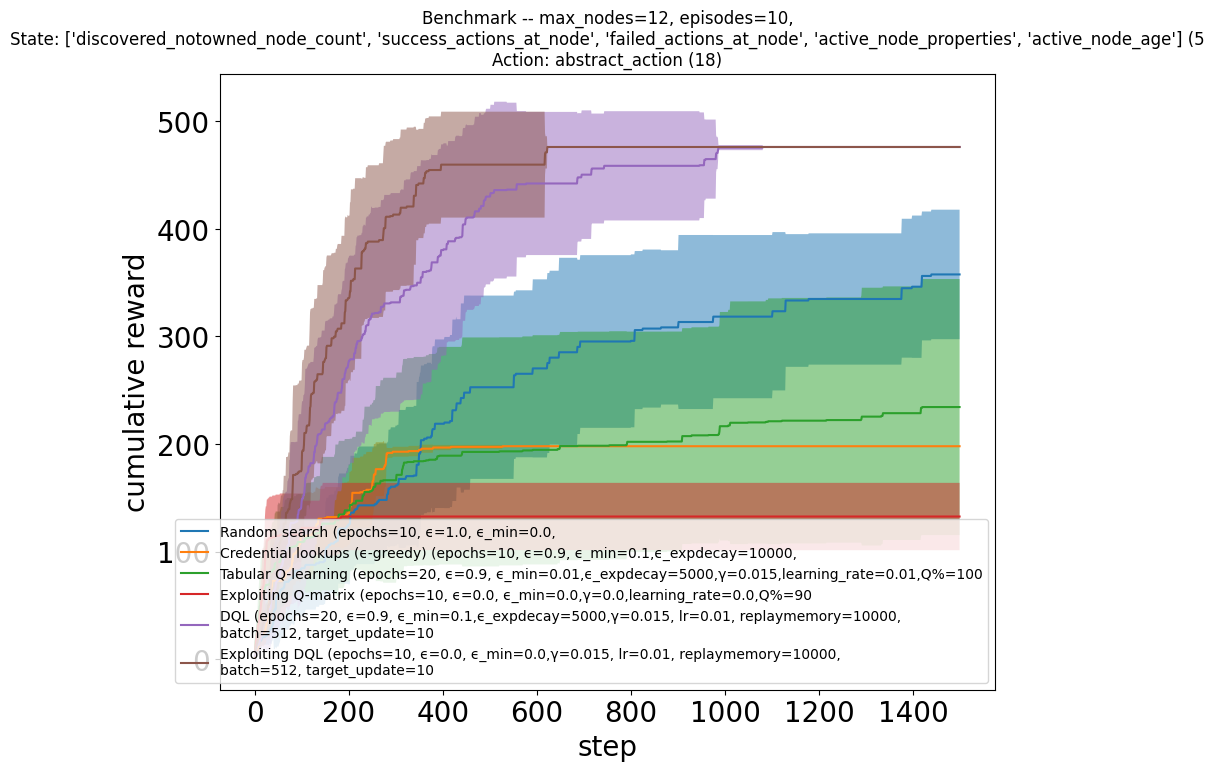

In [ ]:
# Compare and plot results for all the agents
all_runs = [random_run, credlookup_run, tabularq_run, tabularq_exploit_run, dql_run, dql_exploit_run]

# Plot averaged cumulative rewards for DQL vs Random vs DQL-Exploit
themodel = dqla.CyberBattleStateActionModel(ep)


p.plot_averaged_cummulative_rewards(
    all_runs=all_runs,
    title=f"Benchmark -- max_nodes={ep.maximum_node_count}, episodes={eval_episode_count},\n"
    f"State: {[f.name() for f in themodel.state_space.feature_selection]} "
    f"({len(themodel.state_space.feature_selection)}\n"
    f"Action: abstract_action ({themodel.action_space.flat_size()})",
    save_at=os.path.join(plots_dir, f"benchmark-{gymid}-cumrewards.png"),
)

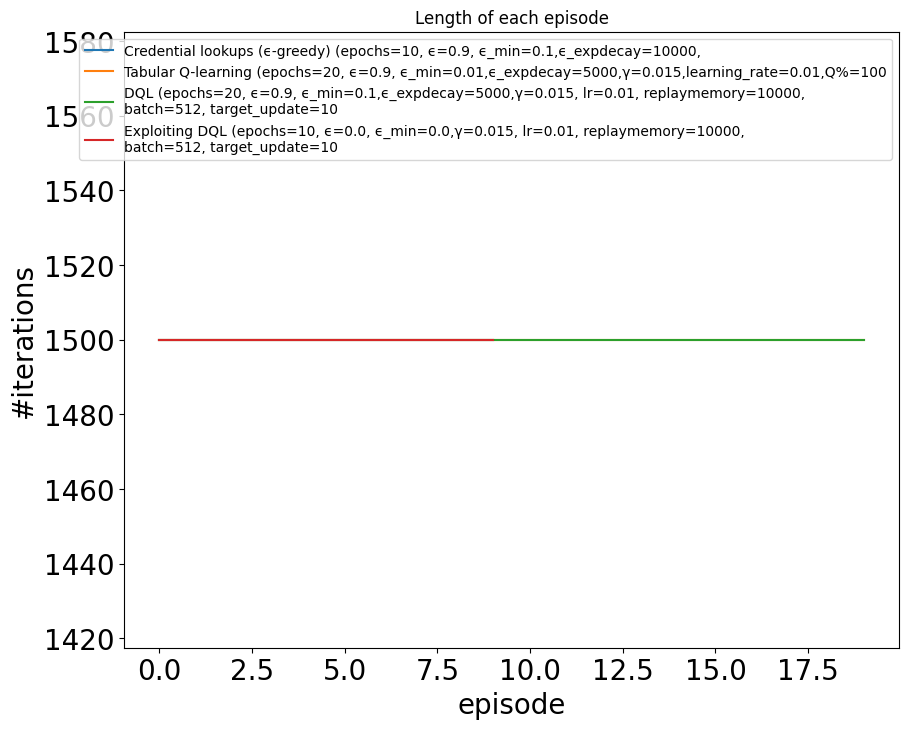

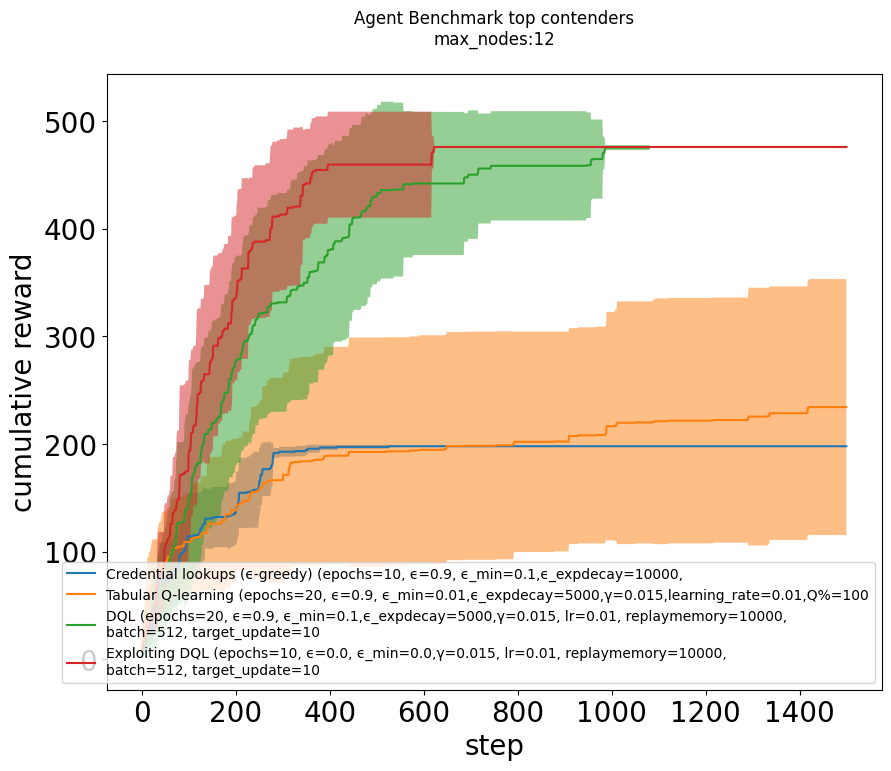

In [ ]:
contenders = [credlookup_run, tabularq_run, dql_run, dql_exploit_run]
p.plot_episodes_length(contenders)
p.plot_averaged_cummulative_rewards(title=f"Agent Benchmark top contenders\n" f"max_nodes:{ep.maximum_node_count}\n", all_runs=contenders,
                                    save_at=os.path.join(plots_dir, f"benchmark-{gymid}-cumreward_contenders.png"))

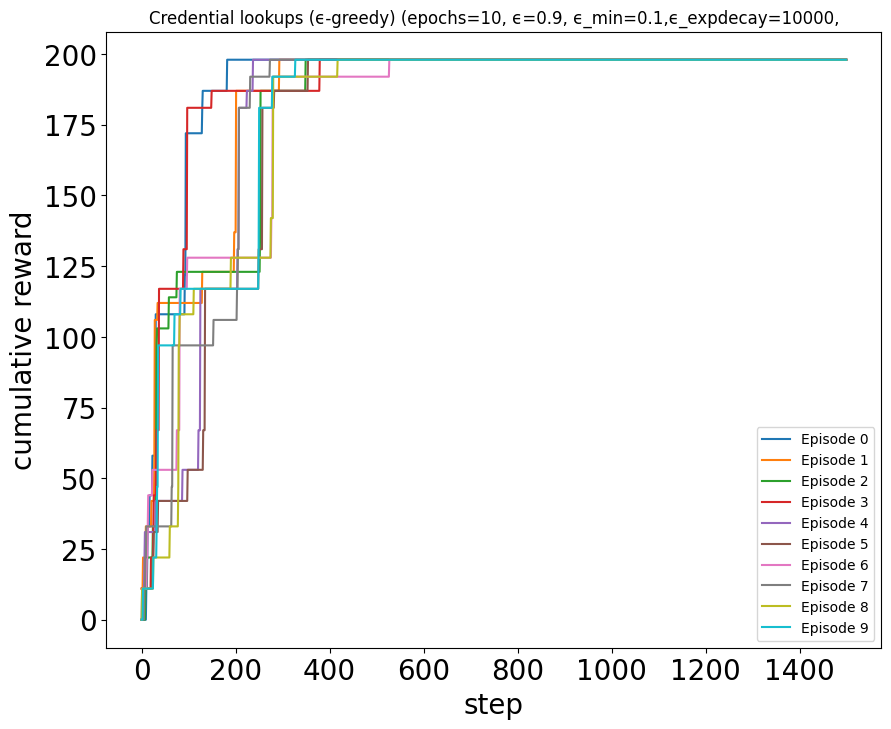

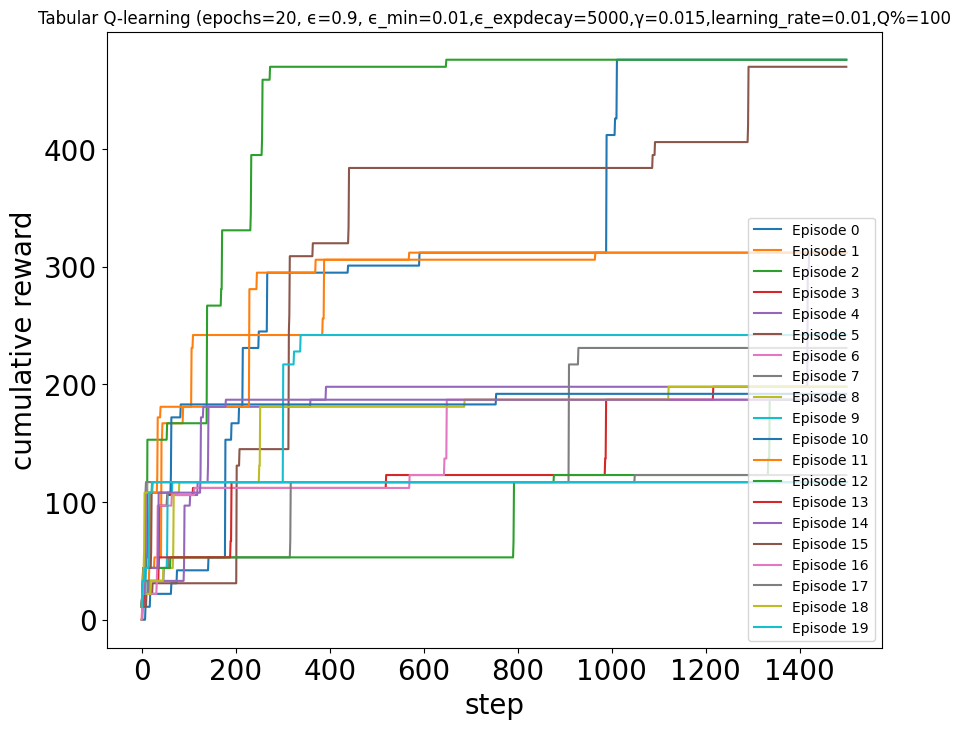

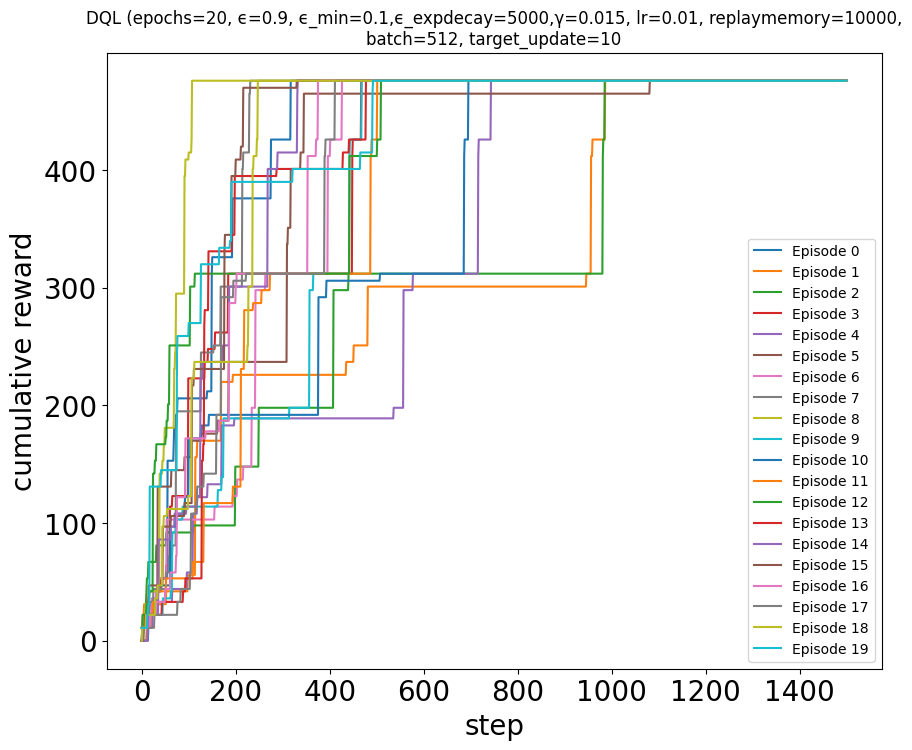

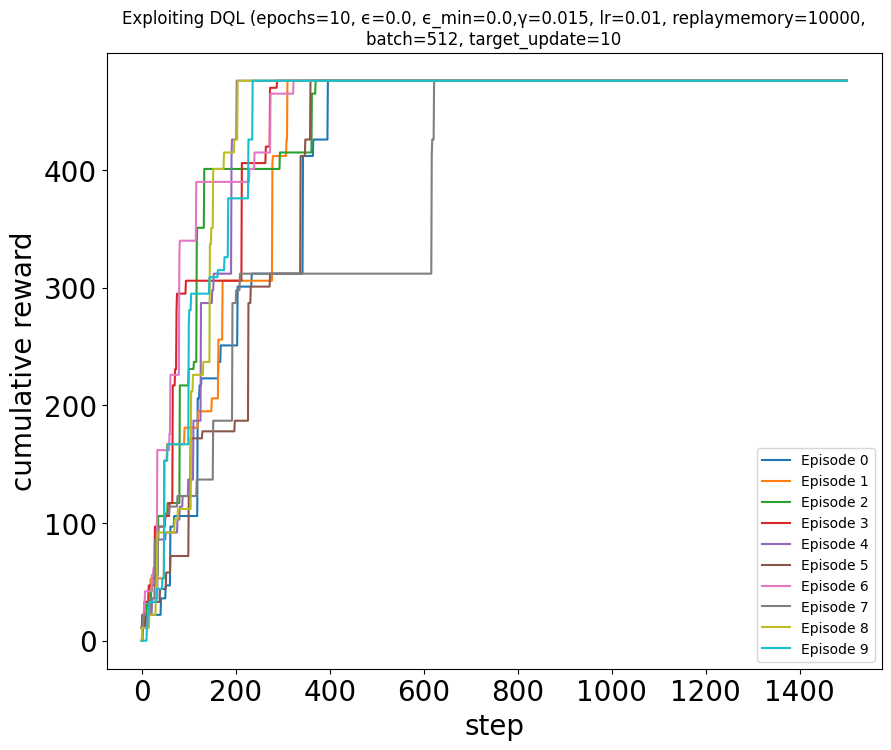

In [ ]:
# Plot cumulative rewards for all episodes
for r in contenders:
    p.plot_all_episodes(r)